In [3]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.core.pipeline import SignalPipeline
from src.core.preprocessing import Preprocessor
from src.filters.lowpass import LowPassFilter
from src.utils.signal_generator import *

# Style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print("Experimentation Environment Ready.")

Experimentation Environment Ready.


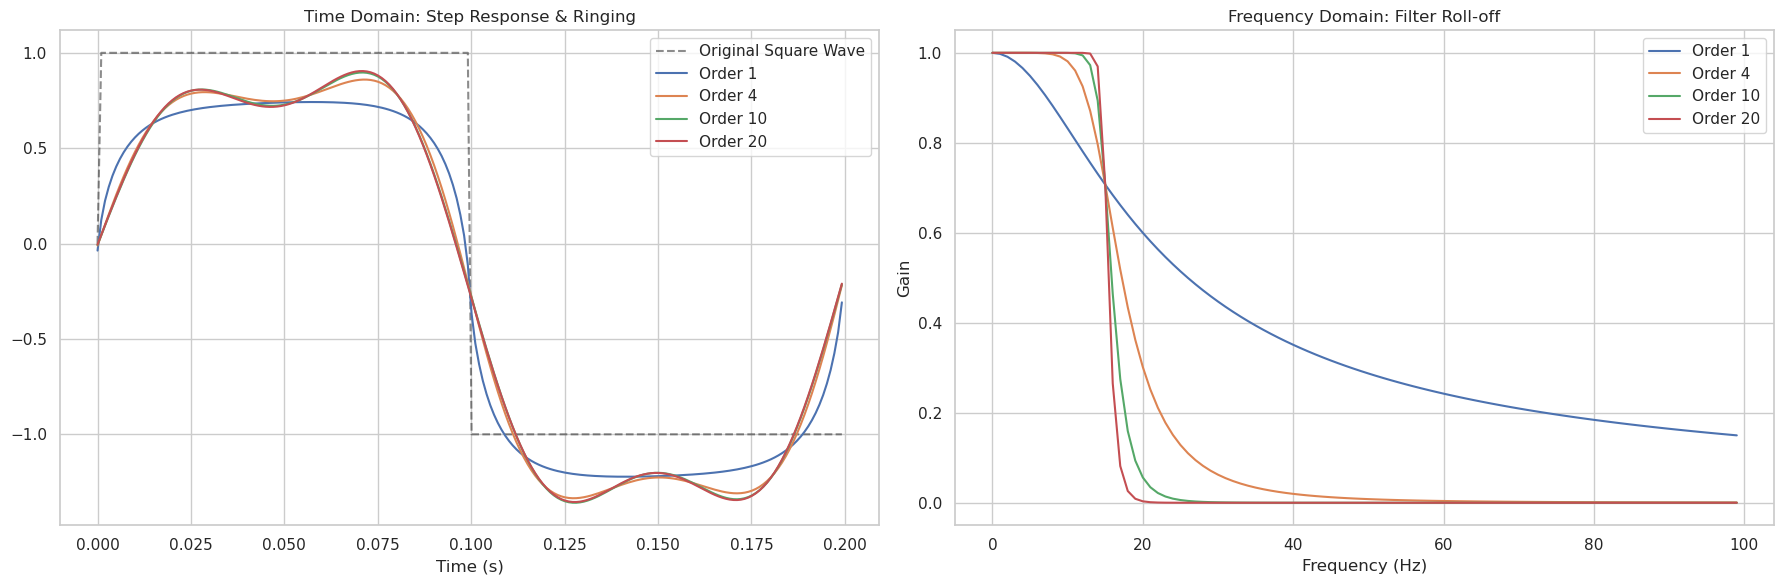

In [4]:
def experiment_filter_order():
    fs = 1000
    duration = 1.0
    gen = SignalGenerator(fs, duration)
    
    # Create a step-like signal to visualize ringing (Gibbs phenomenon)
    t = np.linspace(0, 1, fs)
    # Square wave
    raw_signal = np.sign(np.sin(2 * np.pi * 5 * t)) 
    
    orders = [1, 4, 10, 20]
    cutoff = 15 # Hz
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot original
    ax1.plot(t[:200], raw_signal[:200], 'k--', alpha=0.5, label='Original Square Wave')
    
    results = []
    
    for order in orders:
        # Run Pipeline
        pipeline = SignalPipeline(fs)
        lp_filter = LowPassFilter(cutoff_freq=cutoff, order=order)
        res = pipeline.run(raw_signal, filter_object=lp_filter)
        
        output = res["output_signal"]
        
        # Plot Time Domain (Zoomed in)
        ax1.plot(t[:200], output[:200], label=f'Order {order}')
        
        # Plot Frequency Response (Mask)
        freqs = res["original_spectrum"].frequencies
        mask = lp_filter.compute_mask(freqs)
        ax2.plot(freqs[:100], mask[:100], label=f'Order {order}')

    ax1.set_title("Time Domain: Step Response & Ringing")
    ax1.set_xlabel("Time (s)")
    ax1.legend()
    
    ax2.set_title("Frequency Domain: Filter Roll-off")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Gain")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

experiment_filter_order()

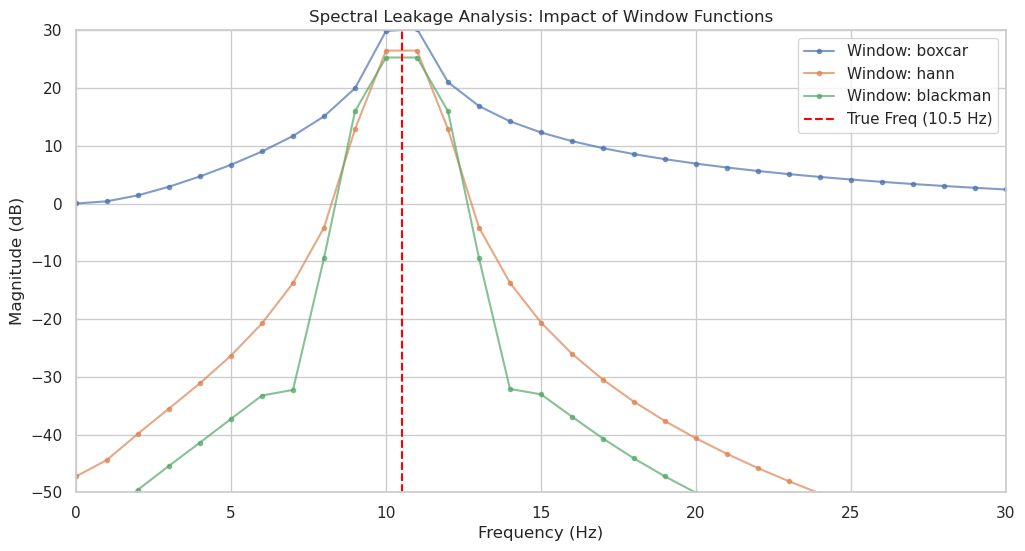

In [5]:
def experiment_windowing():
    fs = 100.0
    # Generate a signal with non-integer cycles to cause leakage
    # 10.5 Hz in a 1-second window
    t = np.linspace(0, 1, int(fs), endpoint=False)
    signal = np.cos(2 * np.pi * 10.5 * t) 
    
    windows = ['boxcar', 'hann', 'blackman'] # boxcar = no window
    
    plt.figure(figsize=(12, 6))
    
    for win_type in windows:
        # Configure Preprocessor
        # We use a temporary config object
        from src.core.config import ProcessingConfig
        config = ProcessingConfig(window_type=win_type, normalize=False, detrend=False)
        
        prep = Preprocessor(config)
        windowed_signal, _ = prep.apply_window(signal, window_type=win_type)
        
        # Compute FFT manually to visualize
        fft_mag = np.abs(np.fft.rfft(windowed_signal))
        freqs = np.fft.rfftfreq(len(signal), 1/fs)
        
        # Convert to dB
        fft_db = 20 * np.log10(fft_mag + 1e-10)
        
        plt.plot(freqs, fft_db, label=f'Window: {win_type}', marker='o', markersize=3, alpha=0.7)

    plt.title("Spectral Leakage Analysis: Impact of Window Functions")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.axvline(10.5, color='red', linestyle='--', label='True Freq (10.5 Hz)')
    plt.legend()
    plt.xlim(0, 30)
    plt.ylim(-50, 30)
    plt.show()

experiment_windowing()

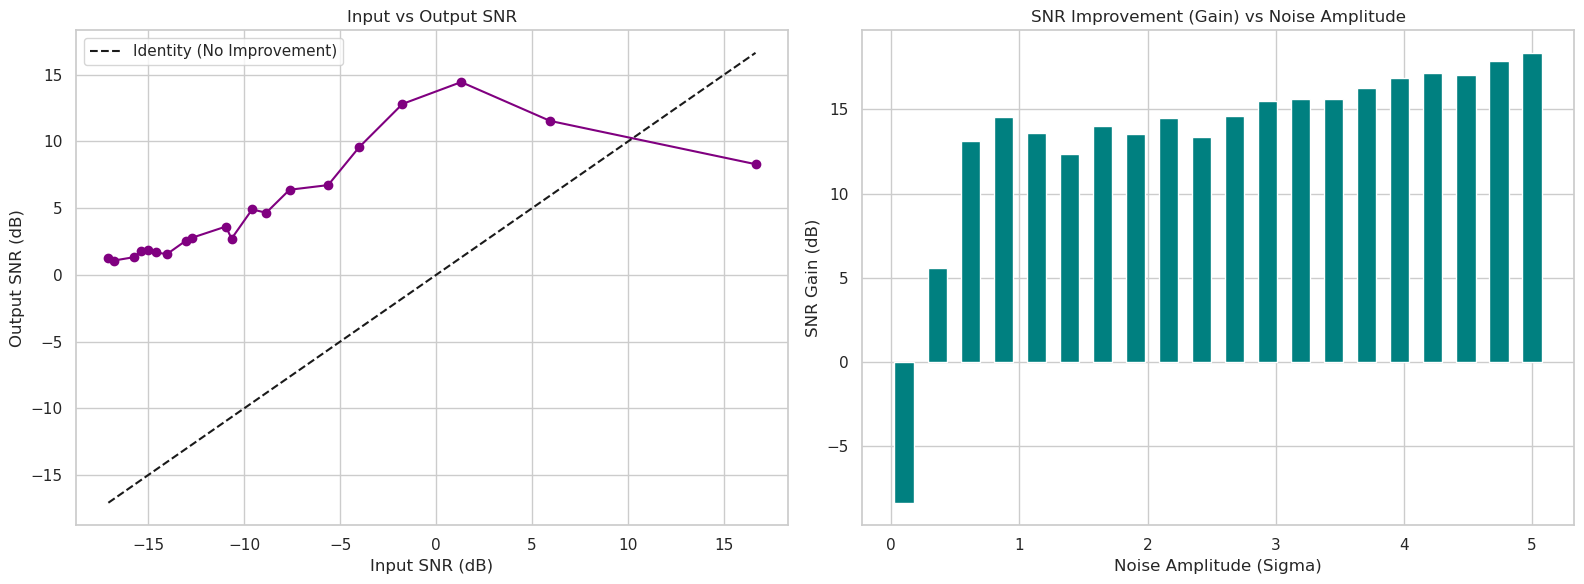

,Noise_Amp,Input_SNR_dB,Output_SNR_dB,Gain_dB
0,0.100000,16.636627,8.293272,-8.343354
1,0.357895,5.933079,11.536324,5.603245
2,0.615789,1.302952,14.444991,13.142039
3,0.873684,-1.755148,12.807076,14.562223
4,1.131579,-4.015332,9.559533,13.574864


In [6]:
def stress_test_snr():
    fs = 1000
    duration = 1.0
    gen = SignalGenerator(fs, duration)
    
    clean_signal = gen.sine_wave(freq=10, amplitude=1.0)
    
    # Noise levels to test
    noise_amplitudes = np.linspace(0.1, 5.0, 20)
    
    results_data = []
    
    pipeline = SignalPipeline(fs)
    # Fixed filter for this test
    lp_filter = LowPassFilter(cutoff_freq=15, order=4)
    
    for n_amp in noise_amplitudes:
        # 1. Create Noisy Signal
        noise = gen.white_noise(amplitude=n_amp)
        raw = clean_signal + noise
        
        # 2. Calculate Input SNR
        input_snr = pipeline.reconstructor.calculate_snr(clean_signal, noise)
        
        # 3. Run Pipeline
        res = pipeline.run(raw, filter_object=lp_filter)
        output = res["output_signal"]
        
        # 4. Calculate Output SNR (Residual noise)
        residual_noise = output - clean_signal
        output_snr = pipeline.reconstructor.calculate_snr(clean_signal, residual_noise)
        
        results_data.append({
            "Noise_Amp": n_amp,
            "Input_SNR_dB": input_snr,
            "Output_SNR_dB": output_snr,
            "Gain_dB": output_snr - input_snr
        })
        
    # Convert to DataFrame
    df = pd.DataFrame(results_data)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Linearity
    ax1.plot(df["Input_SNR_dB"], df["Output_SNR_dB"], 'o-', color='purple')
    ax1.plot([df["Input_SNR_dB"].min(), df["Input_SNR_dB"].max()], 
             [df["Input_SNR_dB"].min(), df["Input_SNR_dB"].max()], 
             'k--', label="Identity (No Improvement)")
    ax1.set_title("Input vs Output SNR")
    ax1.set_xlabel("Input SNR (dB)")
    ax1.set_ylabel("Output SNR (dB)")
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Gain
    ax2.bar(df["Noise_Amp"], df["Gain_dB"], width=0.15, color='teal')
    ax2.set_title("SNR Improvement (Gain) vs Noise Amplitude")
    ax2.set_xlabel("Noise Amplitude (Sigma)")
    ax2.set_ylabel("SNR Gain (dB)")
    
    plt.tight_layout()
    plt.show()
    
    return df

df_results = stress_test_snr()
display(df_results.head())

Signal Size     | Execution Time (ms) 
----------------------------------------
1000            | 3.0363
10000           | 120.8787
100000          | 107.9030
1000000         | 108.0825


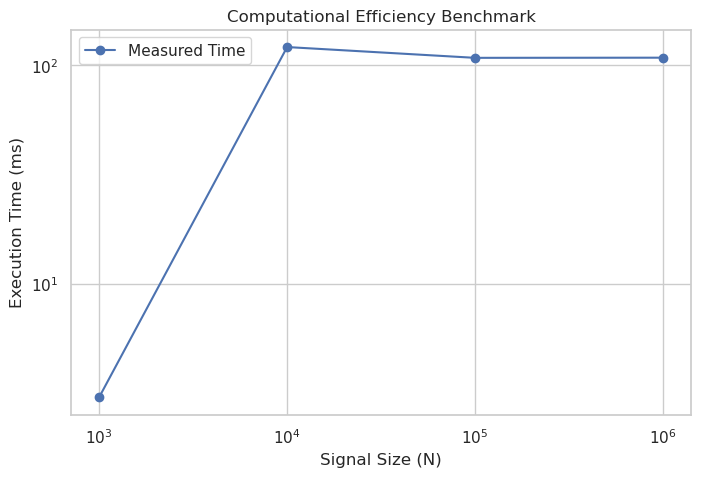

In [7]:
import time

def benchmark_performance():
    sizes = [1000, 10000, 100000, 1000000] # Signal lengths
    fs = 1000
    times = []
    
    lp_filter = LowPassFilter(cutoff_freq=50)
    
    print(f"{'Signal Size':<15} | {'Execution Time (ms)':<20}")
    print("-" * 40)
    
    for N in sizes:
        data = np.random.random(N)
        pipeline = SignalPipeline(fs)
        
        start = time.time()
        _ = pipeline.run(data, filter_object=lp_filter)
        end = time.time()
        
        duration_ms = (end - start) * 1000
        times.append(duration_ms)
        print(f"{N:<15} | {duration_ms:.4f}")

    # Plot O(N log N) trend
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, times, 'bo-', label='Measured Time')
    plt.title("Computational Efficiency Benchmark")
    plt.xlabel("Signal Size (N)")
    plt.ylabel("Execution Time (ms)")
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()

benchmark_performance()